In [41]:
import sys
print(sys.executable)

d:\AI\ai_env\Scripts\python.exe


In [42]:
 
 
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [43]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


50000
10000
torch.Size([3, 32, 32]) 6
frog


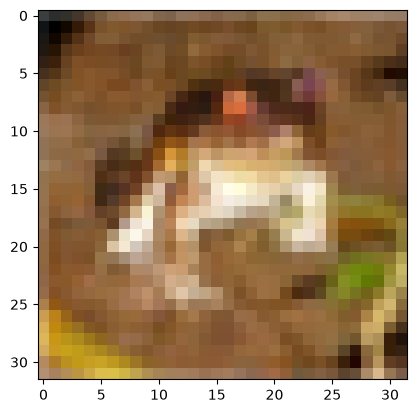

In [44]:
import torchvision
from torchvision import transforms

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

# plot some data
import matplotlib.pyplot as plt
image, label = train_dataset[0]
print(image.shape, label)
plt.imshow(image.permute(1, 2, 0))
print (train_dataset.classes[label])
plt.show()


In [45]:
import torch.nn as nn
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        logits = self.fc(x)
        return logits

model = CIFAR10Model()

In [46]:
# dataloaders
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim

model = CIFAR10Model()

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

epochs = 5
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
correct, total = 0, 0


for epoch in range(epochs):

    # training

    model.train()
    batch_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):

        # forward pass
        pred = model(X)
        loss = loss_fn(pred, y)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()

    print(f"Epoch: {epoch+1}, Loss: {batch_loss/len(train_dataloader ):.4f}")
    


    # evaluation

    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for X_test, y_test in test_dataloader:
        
            outputs = model(X_test)
            # outtputs dim=0 corresponds to the batch size, dim=1 corresponds to the number of classes.
            #  We want to get the index of the class with the highest probability for each sample in the batch, which is why we use argmax along dim=1.
            predictions = outputs.argmax(dim=1)
            correct += (predictions == y_test).sum().item()
            total += len(y_test)
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

Epoch: 1, Loss: 1.4710
Test Accuracy: 0.5488
Epoch: 2, Loss: 1.1057
Test Accuracy: 0.6414
Epoch: 3, Loss: 0.9514
Test Accuracy: 0.6708
Epoch: 4, Loss: 0.8498
Test Accuracy: 0.6794
Epoch: 5, Loss: 0.7772
Test Accuracy: 0.7000
